# Experiment 1 – Random Forest Classifier

Implement a Random Forest classifier on the Iris dataset.  
Train the model using different values of number of estimators and maximum depth.  
Evaluate the model using accuracy, confusion matrix, classification report, and precision-recall curve.

Accuracy: 1.0


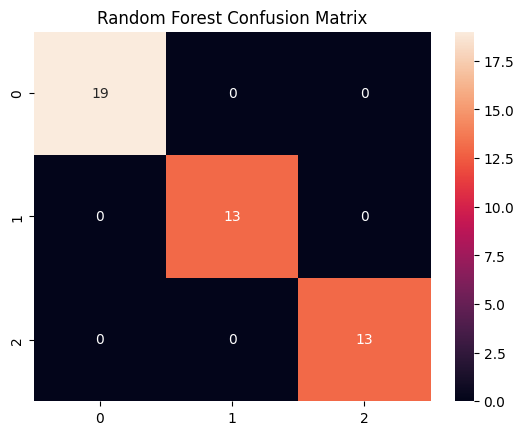


Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



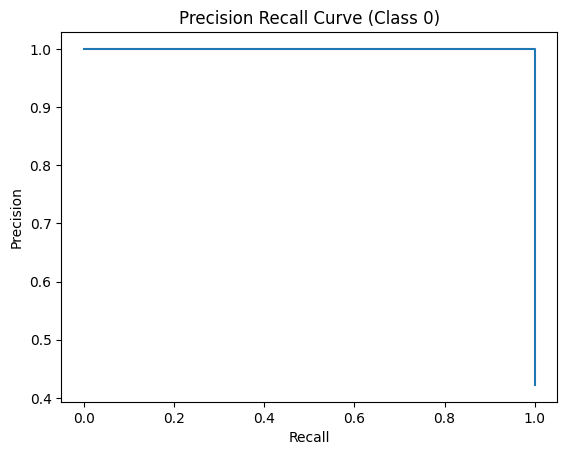

In [1]:
# EXPERIMENT 1 — Random Forest

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve
)
from sklearn.preprocessing import label_binarize

# Load dataset
data = load_iris()
X = data.data
y = data.target

# Binarize for PR curve
y_bin = label_binarize(y, classes=[0,1,2])
n_classes = y_bin.shape[1]

# Split
X_train, X_test, y_train, y_test, y_train_bin, y_test_bin = train_test_split(
    X, y, y_bin, test_size=0.3, random_state=42
)

# Model
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=4,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)


# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Random Forest Confusion Matrix")
plt.show()


# Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Precision Recall curve (one class vs rest)
y_prob = model.predict_proba(X_test)

precision, recall, _ = precision_recall_curve(
    y_test_bin[:,0],   # class 0 vs rest
    y_prob[:,0]
)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision Recall Curve (Class 0)")
plt.show()